# P3_CULTURE 데이터 처리 과정 정리

## 00. 표지

이 노트북은 처리결과보고서와 국정감사 회의록을 원본부터 읽어, 관련 발언 검색과 텍스트 벡터화 과정을 거쳐 최종 Atlas 노드를 만드는 과정을 순서대로 보여줍니다.

- **사용 데이터:** 처리결과보고서 3건, 국정감사 회의록 PDF 42건, 검토 완료 연결·답변유형 데이터
- **최종 결과:** 761개 분석 단위를 24개 주제 구역과 140개 Atlas 노드로 정리
- **전체 흐름:** 원본 확인 → PDF 텍스트 추출 → 발언·문맥 생성 → 관련 후보 검색 → 검토 완료 데이터 → 2차원 지도 → Atlas 노드


## 01. 실행 환경 설정

이번 단계에서는 실행 환경과 무작위 계산의 기준값을 고정합니다. 입력은 제출 폴더이고, 결과는 실행 환경 기록입니다.


In [1]:
import os, sys, re, math, json, random, hashlib, unicodedata, platform
from pathlib import Path
from collections import defaultdict, Counter
from datetime import datetime, timezone
from importlib import metadata

os.environ["PYTHONHASHSEED"] = "42"
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"
os.environ["USE_TF"] = "0"
os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import fitz
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize as l2_normalize
import umap

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
RUN_ID = "P3_SUBMISSION_PIPELINE_V1"
CANONICAL_RELEASE_ID = "ATLAS_DG761_STORY_20260724_022353_KST_BF673FD1"
PROJECTION_ID = "PROJ_DG761_20260723_213011_KST_4665FDF3E5CF"

def find_project_root():
    start = Path.cwd()
    for base in [start, *start.parents]:
        if (base / "P3_CULTURE_DATA_PIPELINE.ipynb").is_file():
            return base
        candidate = base / "P3_CULTURE_SUBMISSION_DATA_PIPELINE"
        if (candidate / "P3_CULTURE_DATA_PIPELINE.ipynb").is_file():
            return candidate
    raise FileNotFoundError("P3_CULTURE_DATA_PIPELINE.ipynb가 있는 제출 폴더를 찾지 못했습니다.")

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
REVIEWED_DIR = DATA_DIR / "reviewed"
MODEL_DIR = PROJECT_ROOT / "models"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
CACHE_DIR = OUTPUT_DIR / "cache"
for directory in [TABLE_DIR, FIGURE_DIR, CACHE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

package_names = ["pandas", "numpy", "pyarrow", "PyMuPDF", "scikit-learn", "scipy", "sentence-transformers", "transformers", "torch", "umap-learn", "matplotlib"]
versions = {name: metadata.version(name) for name in package_names}
environment = {"python": platform.python_version(), "processor": platform.processor() or "CPU", "packages": versions, "seed": SEED}
(CACHE_DIR / "environment.json").write_text(json.dumps(environment, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")
print(pd.DataFrame({"항목": ["Python", "실행 장치", "seed", "경로 방식"], "값": [environment["python"], "CPU", SEED, "제출 폴더 내부 상대경로"]}).to_string(index=False))


    항목             값
Python        3.12.3
 실행 장치           CPU
  seed            42
 경로 방식 제출 폴더 내부 상대경로


Python과 주요 패키지 버전을 기록하고 seed를 42로 고정했습니다. 노트북의 모든 입출력은 제출 폴더 안에서 이루어집니다.


## 02. 파일 경로 설정

이번 단계에서는 원본, 검토 완료 데이터, 모델, 생성 결과의 위치를 확인합니다. 모든 경로는 제출 폴더를 기준으로 만듭니다.


In [2]:
PATHS = {
    "회의록 PDF": RAW_DIR / "meeting_pdfs",
    "처리결과보고서": RAW_DIR / "target_reports",
    "수집·정리 기록": RAW_DIR / "source_registry",
    "검토 완료 데이터": REVIEWED_DIR,
    "MiniLM 모델": MODEL_DIR / "paraphrase-multilingual-MiniLM-L12-v2",
    "결과 표": TABLE_DIR,
    "결과 그림": FIGURE_DIR,
}
path_check = pd.DataFrame([{"구분": name, "상대경로": path.relative_to(PROJECT_ROOT).as_posix(), "존재": path.exists()} for name, path in PATHS.items()])
assert path_check["존재"].all()
print(path_check.to_string(index=False))


       구분                                         상대경로   존재
  회의록 PDF                        data/raw/meeting_pdfs True
  처리결과보고서                      data/raw/target_reports True
 수집·정리 기록                     data/raw/source_registry True
검토 완료 데이터                                data/reviewed True
MiniLM 모델 models/paraphrase-multilingual-MiniLM-L12-v2 True
     결과 표                               outputs/tables True
    결과 그림                              outputs/figures True


원본과 검토 완료 데이터는 `data/` 아래에서 읽고, 새로 계산한 결과만 `outputs/` 아래에 저장합니다. 기존 프로젝트 경로는 사용하지 않습니다.


## 03. 원본 데이터 명세 읽기

이번 단계에서는 두 원본 계열과 기준 행 수를 읽습니다. 결과는 어떤 자료가 어느 단계에 쓰이는지 보여주는 표입니다.


In [3]:
source_cards = pd.read_csv(DATA_DIR / "metadata/DATA_SOURCE_CARDS.csv", encoding="utf-8-sig")
expected_counts = json.loads((DATA_DIR / "metadata/EXPECTED_COUNTS.json").read_text(encoding="utf-8"))
print(source_cards.groupby(["source_family", "year"]).size().rename("파일 수").reset_index().to_string(index=False))
print("\n원본 PDF:", len(source_cards), "건")


source_family  year  파일 수
AUDIT_MINUTES  2020     7
AUDIT_MINUTES  2021     7
AUDIT_MINUTES  2022     7
AUDIT_MINUTES  2023     7
AUDIT_MINUTES  2024     7
AUDIT_MINUTES  2025     7
TARGET_REPORT  2020     1
TARGET_REPORT  2022     1
TARGET_REPORT  2024     1

원본 PDF: 45 건


처리결과보고서는 검색할 문제와 조치 문장을 제공하고, 회의록은 관련 발언을 찾는 원문으로 사용합니다. 두 자료 계열은 서로 다른 역할을 가집니다.


## 04. 원본 파일 무결성 확인

이번 단계에서는 제출 폴더의 PDF를 다시 해시해 명세 카드의 값과 비교합니다. 원본 내용은 읽기만 하며 덮어쓰지 않습니다.


In [4]:
def sha256_file(path):
    h = hashlib.sha256()
    with Path(path).open("rb") as fh:
        for chunk in iter(lambda: fh.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

def source_path(row):
    folder = "meeting_pdfs" if row.source_family == "AUDIT_MINUTES" else "target_reports"
    return RAW_DIR / folder / row.file_name

hash_rows = []
for row in source_cards.itertuples(index=False):
    path = source_path(row)
    actual = sha256_file(path)
    hash_rows.append({"source_id": row.source_id, "파일": row.file_name, "hash_일치": actual == row.sha256, "page_count": row.page_count})
source_hash_check = pd.DataFrame(hash_rows)
assert source_hash_check["hash_일치"].all()
print(source_hash_check.groupby("hash_일치").size().rename("파일 수").to_string())


hash_일치
True    45


45개 원본 PDF의 SHA-256이 모두 명세 카드와 일치합니다. 따라서 이후 계산은 제출 폴더에 포함된 동일 원본을 사용합니다.


## 05. 회의록 PDF 페이지와 텍스트 블록 추출

PyMuPDF의 `page.get_text("blocks", sort=True)` 결과를 읽습니다. 2단 편집 여부를 확인해 읽는 순서를 정하고, 페이지와 텍스트 블록 표를 만듭니다.


In [5]:
registry = pd.read_parquet(RAW_DIR / "source_registry/control_registry.parquet")
PDF_DIR = RAW_DIR / "meeting_pdfs"
PAGE_HEADER_RE = re.compile(r"^(?:\d+\s{0,4})?\d{4}년도국감-문화체육관광\(\d{4}년\d{1,2}월\d{1,2}일\)(?:\s{0,4}\d+)?$")
TIME_MARKER_RE = re.compile(r"^\(\d{1,2}시\d{1,2}분\s?[^()]{0,20}(개의|개시|속개|중지|계속|종료|산회|정회|폐회)\)$")
SPEAKER_HEADER_RE = re.compile(r"^◯")

def normalized_lines_of_block(raw_text):
    return [line.strip() for line in raw_text.split("\n") if line.strip()]

def classify_block(raw_text):
    lines = normalized_lines_of_block(raw_text)
    if not lines: return "EMPTY"
    first = lines[0]
    if PAGE_HEADER_RE.match(first): return "PAGE_HEADER"
    if TIME_MARKER_RE.match(first): return "TIME_MARKER"
    if SPEAKER_HEADER_RE.match(first): return "SPEAKER_HEADER"
    return "BODY_TEXT"

def ordered_text_blocks(page):
    mid_x = page.rect.width / 2.0
    blocks = [block for block in page.get_text("blocks", sort=True) if block[6] == 0]
    nonempty = [block for block in blocks if block[4].strip()]
    if not nonempty: return blocks
    right_ratio = sum(block[0] > mid_x + 10 for block in nonempty) / len(nonempty)
    if right_ratio >= 0.15:
        return sorted(blocks, key=lambda block: (0 if (block[0] + block[2]) / 2.0 < mid_x else 1, block[1], block[0]))
    return sorted(blocks, key=lambda block: (block[1], block[0]))

page_rows, block_rows = [], []
for row in registry.itertuples(index=False):
    with fitz.open(PDF_DIR / f"{row.meeting_id}.pdf") as document:
        for page_index, page in enumerate(document, start=1):
            page_blocks = ordered_text_blocks(page)
            raw_page_text = "".join(block[4] for block in page_blocks)
            page_rows.append({
                "page_no": f"{row.meeting_id}_{page_index:04d}", "meeting_id": row.meeting_id,
                "pdf_page_seq": page_index, "raw_text": raw_page_text,
                "normalized_text": "".join("".join(normalized_lines_of_block(block[4])) for block in page_blocks if classify_block(block[4]) != "PAGE_HEADER"),
                "char_count": len(raw_page_text.strip()), "pipeline_run_id": RUN_ID,
            })
            for block_seq, block in enumerate(page_blocks):
                x0, y0, x1, y1, raw_text, _block_number, block_kind = block
                block_rows.append({
                    "block_no": f"{row.meeting_id}_{page_index:04d}_{block_seq:04d}",
                    "page_no": f"{row.meeting_id}_{page_index:04d}", "meeting_id": row.meeting_id,
                    "pdf_page_seq": page_index, "block_seq": block_seq,
                    "x0": x0, "y0": y0, "x1": x1, "y1": y1,
                    "block_text": raw_text, "normalized_text": "".join(normalized_lines_of_block(raw_text)),
                    "block_type": "IMAGE" if block_kind == 1 else classify_block(raw_text),
                })
pages = pd.DataFrame(page_rows).sort_values(["meeting_id", "pdf_page_seq"]).reset_index(drop=True)
blocks = pd.DataFrame(block_rows).sort_values(["meeting_id", "pdf_page_seq", "block_seq"]).reset_index(drop=True)
pages.to_parquet(TABLE_DIR / "pages.parquet", index=False)
blocks.to_parquet(TABLE_DIR / "blocks.parquet", index=False)
print(pd.DataFrame({"결과": ["회의록 PDF", "페이지", "텍스트 블록"], "행 수": [len(registry), len(pages), len(blocks)]}).to_string(index=False))


     결과    행 수
회의록 PDF     42
    페이지   4495
 텍스트 블록 293717


페이지의 원문과 블록 위치를 함께 보존했습니다. 페이지 머리말, 시간 표시, 화자 머리말, 일반 본문을 구분해 다음 단계에서 발언 경계를 찾습니다.


## 06. 텍스트 정리

문자 모양은 NFKC로 통일하고, 줄바꿈과 연속 공백을 한 칸으로 정리합니다. 원문 열은 그대로 두고 검색용 정리 문장을 별도 열로 만듭니다.


In [6]:
def normalize_text(value):
    if value is None or value is pd.NA or (isinstance(value, float) and math.isnan(value)):
        return ""
    text = unicodedata.normalize("NFKC", str(value)).replace("\x00", "")
    text = re.sub(r"[\r\n]+", " ", text)
    text = re.sub(r"[ \t]+", " ", text)
    return text.strip()

def compact_text(value):
    return re.sub(r"\s+", "", normalize_text(value))

normalization_examples = blocks.loc[blocks["block_text"].str.contains("\n", regex=False, na=False), ["block_no", "block_text"]].head(5).copy()
normalization_examples["정리 후"] = normalization_examples["block_text"].map(normalize_text)
print(normalization_examples.assign(block_text=normalization_examples.block_text.str.slice(0, 90), **{"정리 후": normalization_examples["정리 후"].str.slice(0, 90)}).to_string(index=False))


        block_no                                block_text                               정리 후
050308_0001_0000                2020년도\n국정감사문화체육관광위원회회의록\n            2020년도 국정감사문화체육관광위원회회의록
050308_0001_0001        홍보원․국립아시아문화전당․대한민국예술원사무국․한국정책방송원\n   홍보원.국립아시아문화전당.대한민국예술원사무국.한국정책방송원
050308_0001_0002 일\n시\n2020년10월7일(수)\n장\n소\n문화체육관광위원회회의실\n 일 시 2020년10월7일(수) 장 소 문화체육관광위원회회의실
050308_0001_0003                            (10시07분감사개시)\n                       (10시07분감사개시)
050308_0001_0004                   ◯위원장도종환\n의석을정돈해주시기바랍니\n               ◯위원장도종환 의석을정돈해주시기바랍니


원문은 출처 확인을 위해 보존하고, 검색과 분석에는 정리된 문장을 사용합니다. 어간 추출이나 형태소 분석은 적용하지 않았습니다.


## 07. 화자별 발언 연결

`◯`로 시작하는 화자 머리말을 새 발언의 시작으로 보고, 다음 화자가 나타날 때까지 블록을 이어 붙입니다. 결과는 화자 발언 표입니다.


In [7]:
def build_turns(block_table):
    turn_rows, sequence, current = [], {}, {}
    assigned = []
    for block in block_table.itertuples(index=False):
        meeting_id = block.meeting_id
        active = current.get(meeting_id)
        if block.block_type == "PAGE_HEADER":
            assigned.append(None); continue
        if block.block_type == "SPEAKER_HEADER" or active is None:
            sequence[meeting_id] = sequence.get(meeting_id, 0) + 1
            active = {
                "turn_no": f"{meeting_id}_T{sequence[meeting_id]:05d}", "meeting_id": meeting_id,
                "turn_seq": sequence[meeting_id], "turn_type": "SPEAKER_TURN" if block.block_type == "SPEAKER_HEADER" else "ORPHAN_FRONT_MATTER",
                "speaker_raw": block.normalized_text if block.block_type == "SPEAKER_HEADER" else None,
                "page_start_seq": block.pdf_page_seq, "page_end_seq": block.pdf_page_seq,
                "block_start_no": block.block_no, "block_end_no": block.block_no,
                "block_nos": [], "texts": [],
            }
            turn_rows.append(active); current[meeting_id] = active
        active["block_nos"].append(block.block_no)
        active["texts"].append(block.normalized_text)
        active["page_end_seq"] = block.pdf_page_seq
        active["block_end_no"] = block.block_no
        assigned.append(active["turn_no"])
    block_out = block_table.copy(); block_out["turn_no"] = assigned
    rows = []
    for turn in turn_rows:
        text = "".join(turn.pop("texts"))
        block_nos = turn.pop("block_nos")
        rows.append({**turn, "page_start_no": f"{turn['meeting_id']}_{turn['page_start_seq']:04d}", "page_end_no": f"{turn['meeting_id']}_{turn['page_end_seq']:04d}",
                     "raw_text": text, "normalized_text": text, "char_count": len(text), "n_blocks": len(block_nos),
                     "sentence_count": len(re.findall(r"다\.|까\?|습니다|입니다|[.!?]", text)) or (1 if text else 0)})
    return block_out, pd.DataFrame(rows)

blocks, speaker_turns = build_turns(blocks)
speaker_turns.to_parquet(TABLE_DIR / "speaker_turns.parquet", index=False)
print("화자 발언:", f"{len(speaker_turns):,}", "행")
print(speaker_turns[["turn_no", "speaker_raw", "normalized_text"]].head(3).assign(normalized_text=lambda d: d.normalized_text.str.slice(0, 100)).to_string(index=False))


화자 발언: 65,590 행
      turn_no            speaker_raw                                                                                      normalized_text
050308_T00001                    NaN      2020년도국정감사문화체육관광위원회회의록홍보원․국립아시아문화전당․대한민국예술원사무국․한국정책방송원일시2020년10월7일(수)장소문화체육관광위원회회의실(10시07분감사개시)
050308_T00002    ◯위원장도종환의석을정돈해주시기바랍니 ◯위원장도종환의석을정돈해주시기바랍니다.지금부터헌법제61조, 국회법제127조와국정감사및조사에관한법률에따라문화체육관광부․한국예술종합학교․국립국어원․국립국악원․국립중앙극장․해외문화홍보원
050308_T00003 ◯문화체육관광부장관박양우“선서, 본인은국 ◯문화체육관광부장관박양우“선서, 본인은국회가대한민국헌법제61조, 국회법제127조, 국정감사및조사에관한법률제10조에따라문화체육관광부소관업무에대한2020년도국정감사를실시함에있어기관장으


화자 머리말 사이의 블록을 하나의 발언으로 연결했습니다. 페이지를 넘는 경우에도 같은 화자의 발언은 하나의 행으로 유지됩니다.


## 08. 검색용 문맥 생성

각 발언 자체, 앞 발언과 현재 발언, 현재 발언과 다음 발언의 세 가지 문맥을 만듭니다. 이렇게 하면 짧은 답변도 앞뒤 질문과 함께 검색할 수 있습니다.


In [8]:
segment_rows = []
for meeting_id, group in speaker_turns.sort_values(["meeting_id", "turn_seq"]).groupby("meeting_id", sort=False):
    group = group.reset_index(drop=True)
    for i, row in group.iterrows():
        variants = [("SEG_TURN", i, i)]
        if i > 0: variants.append(("SEG_PREV_CURR", i - 1, i))
        if i + 1 < len(group): variants.append(("SEG_CURR_NEXT", i, i + 1))
        for segment_type, start, end in variants:
            selected = group.iloc[start:end + 1]
            text = "".join(selected["normalized_text"].fillna(""))
            segment_rows.append({
                "segment_no": f"{meeting_id}_{segment_type}_{int(row.turn_seq):05d}", "meeting_id": meeting_id,
                "segment_type": segment_type, "anchor_turn_no": row.turn_no,
                "turn_start_no": selected.iloc[0].turn_no, "turn_end_no": selected.iloc[-1].turn_no,
                "prev_turn_no": group.iloc[i - 1].turn_no if segment_type == "SEG_PREV_CURR" else None,
                "next_turn_no": group.iloc[i + 1].turn_no if segment_type == "SEG_CURR_NEXT" else None,
                "page_start_no": selected.iloc[0].page_start_no, "page_end_no": selected.iloc[-1].page_end_no,
                "raw_text": text, "normalized_text": text, "char_count": len(text), "pipeline_run_id": RUN_ID,
            })
retrieval_segments = pd.DataFrame(segment_rows)
retrieval_segments.to_parquet(TABLE_DIR / "retrieval_segments.parquet", index=False)
print(retrieval_segments["segment_type"].value_counts().rename("행 수").to_string())
print("전체 검색 문맥:", f"{len(retrieval_segments):,}")


segment_type
SEG_TURN         65590
SEG_CURR_NEXT    65548
SEG_PREV_CURR    65548
전체 검색 문맥: 196,686


발언마다 최대 세 개의 검색 문맥을 만들었습니다. 각 문맥에는 원래 회의, 페이지, 발언 번호가 남아 있어 검색 결과를 원문으로 되돌아갈 수 있습니다.


## 09. 화자 역할 정리

화자 머리말에서 위원, 위원장, 장관·기관장과 같은 역할을 구분합니다. 이 구분은 질문과 답변을 순서대로 연결하는 데 사용합니다.


In [9]:
COMMITTEE_ROLES = ["위원장직무대리", "위원장대리", "부위원장", "위원장", "간사", "위원"]
OFFICIAL_ROLES = sorted(set(["사무총장", "상임감사", "상임이사", "대표이사", "이사장", "위원장", "부위원장", "본부장", "담당관", "센터장", "사무국장", "정책관", "연구소장", "극장장", "체육협력관", "협력관", "부서장", "차관", "장관", "청장", "원장", "사장", "회장", "소장", "단장", "국장", "실장", "관장", "총장", "처장", "부장", "과장", "감사", "이사", "대표", "감독", "증인", "참고인"]), key=len, reverse=True)
NAME_CHARS = r"가-힣一-龥"
ORG_SUFFIXES = ("위원회", "문화체육관광부", "체육회", "진흥원", "예술원", "연구원", "박물관", "미술관", "도서관", "극장", "학교", "공사", "공단", "재단", "협회", "센터", "사무국", "부", "처", "청", "원")

def split_official(text, allow_trailing=False):
    candidates = []
    for role in OFFICIAL_ROLES:
        start = 0
        while True:
            pos = text.find(role, start)
            if pos < 0: break
            org, after = text[:pos], pos + len(role)
            for name_length in (3, 2, 4):
                end = after + name_length
                name = text[after:end]
                if end <= len(text) and re.fullmatch(rf"[{NAME_CHARS}]{{{name_length}}}", name) and (allow_trailing or end == len(text)):
                    boundary = end == len(text) or bool(re.match(r"[\s\"“”'(),.!?…]", text[end:end + 1]))
                    score = (12 if name_length == 3 else 5) + min(len(role), 8) * 0.8 + (8 if org.endswith(ORG_SUFFIXES) else 0) + (4 if boundary else 0) - max(pos - 40, 0) * 0.25
                    candidates.append((score, org, role, name, end))
            start = pos + 1
    return sorted(candidates, reverse=True)[0][1:] if candidates else None

def speaker_head(raw_text):
    text = normalize_text(re.sub(r"^\s*[○◯]\s*", "", str(raw_text or "")))[:240]
    member = re.match(rf"^(?P<name>[{NAME_CHARS}]{{2,4}}?)\s*위원(?:님)?", text)
    if member: return f"{member.group('name')}위원"
    chair = re.match(rf"^(?P<role>위원장직무대리|위원장대리|부위원장|위원장|간사)\s*(?P<name>[{NAME_CHARS}]{{2,4}})", text)
    if chair: return f"{chair.group('role')}{chair.group('name')[:3]}"
    official = split_official(compact_text(text), allow_trailing=True)
    return f"{official[0]}{official[1]}{official[2]}" if official else text[:80]

def parse_speaker(head):
    text = compact_text(head)
    result = {"speaker_name": None, "speaker_role": None, "speaker_org": None, "speaker_side": "unknown", "speaker_class": "unknown", "is_question_eligible": False, "is_answer_eligible": False, "parse_confidence": 0.2}
    match = re.match(rf"^(위원장직무대리|위원장대리|부위원장|위원장|간사)([{NAME_CHARS}]{{2,4}})$", text)
    if match:
        role, name = match.groups(); result.update(speaker_name=name, speaker_role=role, speaker_side="procedural" if "위원장" in role else "committee", speaker_class="committee_chair" if "위원장" in role else "committee_member", is_question_eligible=role == "간사", parse_confidence=0.96); return result
    match = re.match(rf"^([{NAME_CHARS}]{{2,4}})위원(?:님)?$", text)
    if match:
        result.update(speaker_name=match.group(1), speaker_role="위원", speaker_side="committee", speaker_class="committee_member", is_question_eligible=True, parse_confidence=0.98); return result
    official = split_official(text)
    if official:
        org, role, name, _ = official; result.update(speaker_name=name, speaker_role=role, speaker_org=org or None, speaker_side="institution", speaker_class="agency_official", is_answer_eligible=True, parse_confidence=0.9)
    return result

block_start_text = blocks.set_index("block_no")["block_text"]
enriched_rows = []
for row in speaker_turns.itertuples(index=False):
    head = speaker_head(block_start_text.get(row.block_start_no, "")) if row.turn_type == "SPEAKER_TURN" else ""
    parsed = parse_speaker(head)
    enriched_rows.append({**row._asdict(), **parsed, "turn_text_raw": row.raw_text, "turn_text_normalized": normalize_text(row.raw_text), "meeting_speaker_id": f"MSP_{row.meeting_id}_{hashlib.sha256((head or row.turn_no).encode()).hexdigest()[:8].upper()}"})
speaker_turns_enriched = pd.DataFrame(enriched_rows)
print(speaker_turns_enriched["speaker_side"].value_counts().rename("발언 수").to_string())


speaker_side
committee      31256
institution    27854
procedural      6148
unknown          332


위원 발언은 질문 후보로, 기관 관계자 발언은 답변 후보로 구분했습니다. 위원장 진행 발언과 구분되지 않은 발언은 질문·답변 연결에서 제외합니다.


## 10. 질문·답변 묶음과 답변 단위 생성

위원 질문 뒤에 이어지는 기관 관계자 발언을 연결합니다. 답변자가 바뀌면 별도 답변 단위로 나눕니다.


In [10]:
qa_rows, answer_rows = [], []
qa_sequence = defaultdict(int)
for meeting_id, group in speaker_turns_enriched.sort_values(["meeting_id", "turn_seq"]).groupby("meeting_id", sort=False):
    group = group.reset_index(drop=True)
    for i, question in group.iterrows():
        if not bool(question.is_question_eligible): continue
        answer_start = None
        for j in range(i + 1, min(len(group), i + 6)):
            candidate = group.iloc[j]
            if bool(candidate.is_question_eligible): break
            if bool(candidate.is_answer_eligible): answer_start = j; break
        if answer_start is None: continue
        answer_indices = [answer_start]
        for j in range(answer_start + 1, min(len(group), answer_start + 4)):
            candidate = group.iloc[j]
            if bool(candidate.is_question_eligible) or candidate.speaker_side == "procedural": break
            if bool(candidate.is_answer_eligible): answer_indices.append(j)
            else: break
        answers = group.iloc[answer_indices]
        qa_sequence[meeting_id] += 1
        qa_id = f"QA_{meeting_id}_{qa_sequence[meeting_id]:06d}"
        qa_rows.append({"qa_pair_id": qa_id, "meeting_id": meeting_id, "question_turn_no": question.turn_no, "question_text": question.turn_text_normalized, "answer_text": " ".join(answers.turn_text_normalized), "page_start_no": question.page_start_no, "page_end_no": answers.iloc[-1].page_end_no})
        current_group = []
        grouped_answers = []
        for answer in answers.itertuples(index=False):
            if current_group and answer.meeting_speaker_id != current_group[-1].meeting_speaker_id:
                grouped_answers.append(current_group); current_group = []
            current_group.append(answer)
        if current_group: grouped_answers.append(current_group)
        for answer_group in grouped_answers:
            first, last = answer_group[0], answer_group[-1]
            answer_id = f"ANS_{meeting_id}_{first.turn_no.split('_')[-1]}_{last.turn_no.split('_')[-1]}"
            text_raw = "\n".join(item.turn_text_raw for item in answer_group)
            text_norm = " ".join(normalize_text(item.turn_text_normalized) for item in answer_group)
            answer_rows.append({"answer_unit_id": answer_id, "qa_pair_id": qa_id, "meeting_id": meeting_id, "answer_turn_start_no": first.turn_no, "answer_turn_end_no": last.turn_no, "page_start_no": first.page_start_no, "page_end_no": last.page_end_no, "primary_segment_no": f"{meeting_id}_SEG_TURN_{int(first.turn_seq):05d}", "answer_text_raw": text_raw, "answer_text_normalized": text_norm, "answer_speaker_name": first.speaker_name, "answer_speaker_org": first.speaker_org})
qa_pairs = pd.DataFrame(qa_rows).drop_duplicates("qa_pair_id")
answer_units = pd.DataFrame(answer_rows).drop_duplicates("answer_unit_id")
qa_pairs.to_parquet(TABLE_DIR / "qa_pairs.parquet", index=False)
answer_units.to_parquet(TABLE_DIR / "answer_units.parquet", index=False)
print(pd.DataFrame({"결과": ["질문·답변 묶음", "답변 단위"], "행 수": [len(qa_pairs), len(answer_units)]}).to_string(index=False))


      결과   행 수
질문·답변 묶음 25958
   답변 단위 26063


질문과 답변을 회의 순서에 따라 연결하고, 같은 답변자의 연속 발언을 하나로 묶었습니다. 각 행에는 회의·페이지·발언 번호가 남습니다.


## 11. 처리결과보고서 문장 정리

세 보고서에서 사람이 표시해 확정한 문제·조치 행을 읽습니다. 원본 PDF는 해시와 페이지 수를 확인하고, 검색 문장은 marker mapping의 원문을 정리해 사용합니다.


In [11]:
target_rows = []
for year in (2020, 2022, 2024):
    mapping = pd.read_csv(RAW_DIR / f"source_registry/{year}_marked_issue_mapping.csv", encoding="utf-8-sig", keep_default_na=False)
    for row in mapping.itertuples(index=False):
        issue_no = int(row.issue_no)
        action = normalize_text(row.action_text)
        if action.lower() == "null": action = ""
        target_rows.append({"target_issue_id": f"TGT_{year}_{issue_no:04d}", "source_year": year, "audit_cycle": f"AUDIT_{year}", "source_row_no": issue_no, "source_page": int(row.source_page), "issue_text_raw": row.issue_text, "issue_text": normalize_text(row.issue_text), "action_text_raw": row.action_text, "action_text": action, "reported_status": row.status})
target_issues = pd.DataFrame(target_rows).sort_values(["source_year", "source_row_no"]).reset_index(drop=True)
target_issues["query_text"] = (target_issues["issue_text"] + " " + target_issues["action_text"]).str.strip()
target_issues.to_parquet(TABLE_DIR / "target_issues.parquet", index=False)
print(target_issues.groupby("source_year").size().rename("검색 문장 수").to_string())
print("전체 검색 쿼리:", len(target_issues))


source_year
2020    110
2022    116
2024     71
전체 검색 쿼리: 297


문제 문장과 조치 문장을 각각 보존하고 검색용으로 정리했습니다. 조치 문장이 없는 행은 문제 문장만 사용합니다.


## 16. TF-IDF 1차 후보 검색

같은 감사 연도의 회의록만 대상으로 문자 3~5개 묶음과 단어 1~2개 묶음을 숫자로 바꿉니다. 문제 벡터에 조치 벡터의 25%를 더하고, 문자 점수 65%와 단어 점수 35%를 합쳐 쿼리마다 상위 50개를 고릅니다.


In [12]:
meeting_year = {row.meeting_id: 2000 + int(row.meeting_year) for row in registry.itertuples(index=False)}
turn_text = speaker_turns_enriched.set_index("turn_no")["turn_text_normalized"].fillna("").to_dict()
search_segments = retrieval_segments.copy()
search_segments["search_text_normalized"] = [normalize_text(" ".join([turn_text.get(start, ""), turn_text.get(end, "") if end != start else ""])) for start, end in zip(search_segments.turn_start_no, search_segments.turn_end_no)]
search_segments["search_text_compact"] = search_segments["search_text_normalized"].map(compact_text)
search_segments["source_year"] = search_segments["meeting_id"].map(meeting_year)

candidate_rows = []
for year in sorted(target_issues.source_year.unique()):
    corpus = search_segments[search_segments.source_year == year].reset_index(drop=True)
    queries = target_issues[target_issues.source_year == year].reset_index(drop=True)
    char_vectorizer = TfidfVectorizer(analyzer="char", ngram_range=(3, 5), min_df=2, max_features=120000, sublinear_tf=True, norm="l2")
    word_vectorizer = TfidfVectorizer(analyzer="word", ngram_range=(1, 2), token_pattern=r"(?u)\b\w+\b", min_df=2, max_features=80000, sublinear_tf=True, norm="l2")
    char_documents = char_vectorizer.fit_transform(corpus.search_text_compact.fillna(""))
    word_documents = word_vectorizer.fit_transform(corpus.search_text_normalized.fillna(""))
    q_issue_char = char_vectorizer.transform(queries.issue_text.map(compact_text)); q_action_char = char_vectorizer.transform(queries.action_text.map(compact_text))
    q_issue_word = word_vectorizer.transform(queries.issue_text.map(normalize_text)); q_action_word = word_vectorizer.transform(queries.action_text.map(normalize_text))
    q_char = l2_normalize(q_issue_char + 0.25 * q_action_char); q_word = l2_normalize(q_issue_word + 0.25 * q_action_word)
    for index, query in queries.iterrows():
        char_scores = (q_char[index] @ char_documents.T).toarray().ravel()
        word_scores = (q_word[index] @ word_documents.T).toarray().ravel()
        sparse_scores = 0.65 * char_scores + 0.35 * word_scores
        top_index = np.argpartition(-sparse_scores, 49)[:50]
        top_index = top_index[np.argsort(-sparse_scores[top_index], kind="stable")]
        char_rank = pd.Series(char_scores[top_index]).rank(method="first", ascending=False).astype(int).to_numpy()
        word_rank = pd.Series(word_scores[top_index]).rank(method="first", ascending=False).astype(int).to_numpy()
        for rank, (document_index, c_rank, w_rank) in enumerate(zip(top_index, char_rank, word_rank), start=1):
            segment = corpus.iloc[int(document_index)]
            candidate_rows.append({"candidate_id": f"CAND_{query.target_issue_id}_{hashlib.sha256(segment.segment_no.encode()).hexdigest()[:8].upper()}", "target_issue_id": query.target_issue_id, "segment_no": segment.segment_no, "meeting_id": segment.meeting_id, "source_year": year, "char_score": float(char_scores[document_index]), "word_score": float(word_scores[document_index]), "sparse_score": float(sparse_scores[document_index]), "char_rank": int(c_rank), "word_rank": int(w_rank), "sparse_rank": rank, "search_text": segment.search_text_normalized})
retrieval_candidates = pd.DataFrame(candidate_rows)
print("TF-IDF 후보:", f"{len(retrieval_candidates):,}", "행 / 쿼리당", retrieval_candidates.groupby("target_issue_id").size().min(), "~", retrieval_candidates.groupby("target_issue_id").size().max())


TF-IDF 후보: 14,850 행 / 쿼리당 50 ~ 50


감사 연도가 다른 회의록은 후보에서 제외했습니다. 각 문제마다 50개 후보를 남겨 다음 의미 기반 재정렬의 계산 범위를 제한했습니다.


## 17. MiniLM 의미 기반 재정렬

로컬 MiniLM 모델은 문장을 384개의 숫자로 바꿉니다. 전체 회의록이 아니라 TF-IDF가 고른 후보 문맥만 변환하며, 인터넷 연결은 사용하지 않습니다.


In [13]:
from sentence_transformers import SentenceTransformer

model_path = MODEL_DIR / "paraphrase-multilingual-MiniLM-L12-v2"
dense_model = SentenceTransformer(str(model_path), device="cpu", local_files_only=True)
unique_segments = retrieval_candidates[["segment_no", "search_text"]].drop_duplicates("segment_no").reset_index(drop=True)
dense_queries = target_issues[["target_issue_id", "query_text"]].copy()
segment_vectors = dense_model.encode(unique_segments.search_text.fillna("").tolist(), batch_size=32, show_progress_bar=True, normalize_embeddings=True, convert_to_numpy=True).astype("float32")
query_vectors = dense_model.encode(dense_queries.query_text.tolist(), batch_size=32, show_progress_bar=True, normalize_embeddings=True, convert_to_numpy=True).astype("float32")
segment_position = {value: i for i, value in enumerate(unique_segments.segment_no)}
query_position = {value: i for i, value in enumerate(dense_queries.target_issue_id)}
retrieval_candidates["dense_score"] = [float(query_vectors[query_position[target]] @ segment_vectors[segment_position[segment]]) for target, segment in zip(retrieval_candidates.target_issue_id, retrieval_candidates.segment_no)]
retrieval_candidates["dense_rank"] = retrieval_candidates.groupby("target_issue_id")["dense_score"].rank(method="first", ascending=False).astype(int)
np.save(CACHE_DIR / "minilm_candidate_vectors.npy", segment_vectors)
unique_segments[["segment_no"]].assign(vector_row=np.arange(len(unique_segments))).to_csv(CACHE_DIR / "minilm_candidate_vector_index.csv", index=False)
print("MiniLM 입력 후보 문맥:", len(unique_segments), "고유 문맥 /", len(dense_queries), "쿼리 / 차원", segment_vectors.shape[1])


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/346 [00:00<?, ?it/s]

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

MiniLM 입력 후보 문맥: 11067 고유 문맥 / 297 쿼리 / 차원 384


MiniLM은 TF-IDF 후보의 문장 전체 의미를 비교하는 보조 단계입니다. 질문·조치 문장과 후보 문맥의 cosine 유사도가 높을수록 앞 순서가 됩니다.


## 18. 후보 순서 합치기

문자 TF-IDF, 단어 TF-IDF, MiniLM의 세 순위를 RRF 방식으로 합칩니다. 점수 크기 자체보다 세 방법에서 고르게 앞선 후보를 우선합니다.


In [14]:
retrieval_candidates["rrf_score"] = 1 / (60 + retrieval_candidates.char_rank) + 1 / (60 + retrieval_candidates.word_rank) + 1 / (60 + retrieval_candidates.dense_rank)
retrieval_candidates = retrieval_candidates.sort_values(["target_issue_id", "rrf_score", "candidate_id"], ascending=[True, False, True]).reset_index(drop=True)
retrieval_candidates["final_rank"] = retrieval_candidates.groupby("target_issue_id").cumcount() + 1
retrieval_candidates.to_parquet(TABLE_DIR / "retrieval_candidates.parquet", index=False)
print(retrieval_candidates[["target_issue_id", "segment_no", "sparse_score", "dense_score", "rrf_score", "final_rank"]].head(10).to_string(index=False))


target_issue_id                 segment_no  sparse_score  dense_score  rrf_score  final_rank
  TGT_2020_0004      050350_SEG_TURN_00217      0.101614     0.573758   0.042383           1
  TGT_2020_0004      050430_SEG_TURN_01139      0.086652     0.480298   0.040219           2
  TGT_2020_0004      050308_SEG_TURN_00074      0.101966     0.448983   0.039847           3
  TGT_2020_0004      050430_SEG_TURN_00736      0.080677     0.502845   0.039826           4
  TGT_2020_0004      050430_SEG_TURN_00137      0.126402     0.284450   0.039772           5
  TGT_2020_0004 050430_SEG_CURR_NEXT_00736      0.074593     0.509505   0.039423           6
  TGT_2020_0004      050308_SEG_TURN_00570      0.139818     0.182078   0.039166           7
  TGT_2020_0004 050350_SEG_CURR_NEXT_00216      0.094822     0.517693   0.039153           8
  TGT_2020_0004 050430_SEG_PREV_CURR_00737      0.074593     0.509505   0.038891           9
  TGT_2020_0004 050350_SEG_PREV_CURR_00217      0.094822     0.517693 

세 검색 방법의 순위를 하나로 합쳐 14,850개 후보 표를 만들었습니다. 이 표는 사람이 실제 관련 발언을 확인하기 위한 출발점입니다.


## 19. 검토 완료 데이터 사용

자동 검색 결과 중 실제 관련성이 확인된 항목은 검토 완료 데이터로 저장하였으며, 이후 지도 생성 단계에서는 이 검토 완료 데이터를 사용했습니다.

- 원본 PDF부터 검색 후보 생성: 이 노트북이 직접 재현
- 검색 후보에 대한 사람의 검토 결과: 제출 폴더의 reviewed 데이터 사용
- 검토 완료 데이터 이후의 벡터화·투영·노드 생성: 이 노트북이 직접 재현


In [15]:
decision_groups = pd.read_parquet(REVIEWED_DIR / "decision_groups.parquet").sort_values("projection_entity_id").reset_index(drop=True)
answer_behavior_labels = pd.read_parquet(REVIEWED_DIR / "answer_behavior_labels.parquet")
reviewed_links = pd.read_parquet(REVIEWED_DIR / "reviewed_links.parquet")
print(pd.DataFrame({"검토 완료 자료": ["분석 단위", "답변행태 라벨", "관련 발언 연결"], "행 수": [len(decision_groups), len(answer_behavior_labels), len(reviewed_links)]}).to_string(index=False))


검토 완료 자료  행 수
   분석 단위  761
 답변행태 라벨  769
관련 발언 연결   64


사람이 확인한 연결과 답변유형은 자동으로 다시 판단하지 않습니다. 이후 계산은 761개 검토 완료 분석 단위를 그대로 입력으로 사용합니다.


## 20. 지도용 문장을 숫자로 변환

각 분석 단위의 대표 문장을 문자 TF-IDF로 바꾸고, SVD로 96개 핵심 특징으로 줄입니다. 마지막으로 각 행의 길이를 1로 맞춰 문장 방향을 비교합니다.


In [16]:
map_vectorizer = TfidfVectorizer(analyzer="char", ngram_range=(2, 5), min_df=2, max_features=8192, sublinear_tf=True, norm="l2", dtype=np.float64)
map_sparse = map_vectorizer.fit_transform(decision_groups.topic_anchor_text_normalized.tolist())
svd = TruncatedSVD(n_components=96, n_iter=15, random_state=SEED)
embedding_matrix = l2_normalize(svd.fit_transform(map_sparse), norm="l2")
embedding_columns = [f"embedding_{i:03d}" for i in range(96)]
embedding_table = pd.DataFrame(embedding_matrix, columns=embedding_columns)
embedding_table.insert(0, "projection_entity_id", decision_groups.projection_entity_id)
embedding_table.to_parquet(CACHE_DIR / "embedding_matrix.parquet", index=False)
import joblib
joblib.dump({"vectorizer": map_vectorizer, "svd": svd}, CACHE_DIR / "text_vectorizer_svd.joblib", compress=3)
print("입력 문장:", embedding_matrix.shape[0], "/ SVD 차원:", embedding_matrix.shape[1], "/ TF-IDF 특징:", map_sparse.shape[1])


입력 문장: 761 / SVD 차원: 96 / TF-IDF 특징: 8192


수천 개의 문자 특징을 96개의 핵심 패턴으로 줄였습니다. 이 96차원 값이 주제 구역과 2차원 위치 계산의 공통 입력입니다.


## 21. UMAP 2차원 좌표 생성

96차원 문장 특징을 화면에서 볼 수 있도록 UMAP으로 가로·세로 좌표를 만듭니다. 모든 상태를 한 번에 계산하고 결과 범위를 0부터 1 사이로 맞춥니다.


In [17]:
reducer = umap.UMAP(n_components=2, n_neighbors=20, min_dist=0.08, metric="cosine", random_state=SEED, transform_seed=SEED, n_jobs=1)
raw_xy = reducer.fit_transform(embedding_matrix)
minimum, maximum = raw_xy.min(axis=0), raw_xy.max(axis=0)
xy = (raw_xy - minimum) / np.where(maximum > minimum, maximum - minimum, 1.0)
projection_points = pd.DataFrame({"projection_id": PROJECTION_ID, "projection_entity_id": decision_groups.projection_entity_id, "x": np.round(xy[:, 0], 12), "y": np.round(xy[:, 1], 12)})
projection_points.to_csv(TABLE_DIR / "projection_points.csv", index=False)
joblib.dump(reducer, CACHE_DIR / "umap_model.joblib", compress=3)
print(projection_points.head().to_string(index=False))


                              projection_id        projection_entity_id        x        y
PROJ_DG761_20260723_213011_KST_4665FDF3E5CF PE_00801BEDF4A255BA7B33F53F 0.767242 0.155885
PROJ_DG761_20260723_213011_KST_4665FDF3E5CF PE_00F234937E28BF44BE6A7FAA 0.132009 0.760142
PROJ_DG761_20260723_213011_KST_4665FDF3E5CF PE_00F25AAE48F26CF8A3D6FDC3 0.309553 0.329232
PROJ_DG761_20260723_213011_KST_4665FDF3E5CF PE_00F671FF017D13F56132EF45 0.605725 0.358869
PROJ_DG761_20260723_213011_KST_4665FDF3E5CF PE_01143090221983D72023BF68 0.156528 0.706748


각 분석 단위에 2차원 좌표를 부여했습니다. 이 좌표는 화면 배치를 위한 값이며, 거리만으로 실제 정책 효과를 판단하지 않습니다.


## 22. 24개 주제 구역과 대표 문장

KMeans로 비슷한 문장을 24개 구역으로 나눕니다. 각 구역에서 다른 문장들과 평균 cosine 유사도가 가장 높은 문장을 대표 문장으로 선택합니다.


In [18]:
def stable_id(prefix, *parts):
    payload = "\x1f".join("" if value is None else str(value) for value in parts).encode()
    return f"{prefix}_{hashlib.sha256(payload).hexdigest()[:24].upper()}"

def medoid_index(indices, matrix):
    if len(indices) == 1: return indices[0]
    similarities = cosine_similarity(matrix[indices])
    return indices[int(np.argmax(similarities.mean(axis=1)))]

kmeans = KMeans(n_clusters=24, random_state=SEED, n_init=40, algorithm="lloyd").fit(embedding_matrix)
topic_rows, topic_member_rows = [], []
for cluster in sorted(set(kmeans.labels_)):
    indices = np.flatnonzero(kmeans.labels_ == cluster).tolist()
    representative = medoid_index(indices, embedding_matrix)
    topic_id = stable_id("TBIN", PROJECTION_ID, cluster)
    topic_rows.append({"topic_bin_id": topic_id, "cluster_number": int(cluster), "member_count": len(indices), "center_x": float(xy[indices, 0].mean()), "center_y": float(xy[indices, 1].mean()), "representative_entity_id": decision_groups.loc[representative, "projection_entity_id"], "representative_text": decision_groups.loc[representative, "topic_anchor_text_normalized"][:160]})
    topic_member_rows.extend({"topic_bin_id": topic_id, "projection_entity_id": decision_groups.loc[index, "projection_entity_id"]} for index in indices)
topic_bins = pd.DataFrame(topic_rows)
topic_members = pd.DataFrame(topic_member_rows)
topic_bins.to_csv(TABLE_DIR / "topic_bins.csv", index=False)
topic_members.to_parquet(TABLE_DIR / "topic_bin_members.parquet", index=False)
joblib.dump(kmeans, CACHE_DIR / "kmeans_model.joblib", compress=3)
print(topic_bins[["cluster_number", "member_count", "representative_text"]].sort_values("cluster_number").to_string(index=False, max_colwidth=70))


 cluster_number  member_count                                                    representative_text
              0            76 ◯이상헌 위원 몇 차례 열렸다고요? 1년에 200건 넘게 접수가 신고되는데 사건을 심의하는 위원회 는 고작 1년에 한 번...
              1            17  ◯조은희위원 청장님답변이제가이해하기어려울정도로굉장히두루뭉술하세요. 제 질문은화재가나면대웅전과천왕문이보상받느냐는걸물어봤습니다.
              2            46                                                       ◯김승수 위원 어떻게 됩니까?
              3            29                                             ◯민형배위원 피감기관은맞는데오늘참석대상이아니다?
              4           108 ◯류호정 위원 정의당 류호정입니다. 스포츠윤리센터 이사장직무대리님 그리고 대한 체육회 회장님께서 좀 들어 주시기 바라겠습...
              5            46                                              ◯임오경위원 10년이넘는상황에서2건에불과하다?
              6            35                                              스크린상한제및배급-상영업 겸업금지도입에협조할것
              7            27                                                         ◯조계원위원 경찰청하고요?
              8            22                                                           ◯박정

24개 주제 구역은 96차원 문장 특징을 기준으로 계산했습니다. 대표 문장은 각 구역의 중심에 가장 가까운 실제 문장이므로 새 문장을 만들어 붙이지 않습니다.


## 23. Atlas 노드 생성

같은 주제와 처리 상태, 답변 방식에 속한 여러 분석 단위를 하나의 노드로 묶었습니다. 노드 위치는 구성원 좌표의 평균이며, 크기는 구성원 신뢰도 합계를 화면 크기로 변환한 값입니다.


In [19]:
analysis = decision_groups.merge(topic_members, on="projection_entity_id", validate="one_to_one")
analysis = analysis.merge(projection_points[["projection_entity_id", "x", "y"]], on="projection_entity_id", validate="one_to_one")
node_rows, member_rows = [], []
for (status, topic_id, answer_type), group in analysis.groupby(["status", "topic_bin_id", "primary_answer_type_code"], sort=True):
    indices = group.index.to_list()
    local_indices = [decision_groups.index[decision_groups.projection_entity_id == entity].item() for entity in group.projection_entity_id]
    representative = medoid_index(local_indices, embedding_matrix)
    node_id = stable_id("ANODE", PROJECTION_ID, status, topic_id, answer_type)
    weight = float(group.combined_confidence.sum())
    node_rows.append({"node_id": node_id, "topic_bin_id": topic_id, "status": status, "answer_type": answer_type, "member_count": len(group), "x": float(group.x.mean()), "y": float(group.y.mean()), "weighted_mass": weight, "node_size": 0.0, "representative_text": decision_groups.loc[representative, "topic_anchor_text_normalized"][:160]})
    member_rows.extend({"node_id": node_id, "projection_entity_id": entity, "topic_bin_id": topic_id, "status": status, "answer_type": answer_type} for entity in group.projection_entity_id)
atlas_nodes = pd.DataFrame(node_rows)
maximum_mass = atlas_nodes.weighted_mass.max()
atlas_nodes["node_size"] = 7 + 15 * np.sqrt(atlas_nodes.weighted_mass / maximum_mass)
atlas_node_members = pd.DataFrame(member_rows)
atlas_nodes.to_csv(TABLE_DIR / "atlas_nodes.csv", index=False)
atlas_node_members.to_parquet(TABLE_DIR / "atlas_node_members.parquet", index=False)
print("분석 단위:", len(atlas_node_members), "→ Atlas 노드:", len(atlas_nodes))


분석 단위: 761 → Atlas 노드: 140


노드 하나는 처리 상태 × 주제 구역 × 대표 답변유형의 조합입니다. 761개 분석 단위가 중복 없이 하나씩 포함되어 140개 노드가 되었습니다.


## 24. 결과 시각화

처리 단계별 규모, 연도별 회의록 수, 주제 분포, 분석 단위 지도, Atlas 노드 지도, 답변유형별 노드 수를 그림으로 저장합니다.


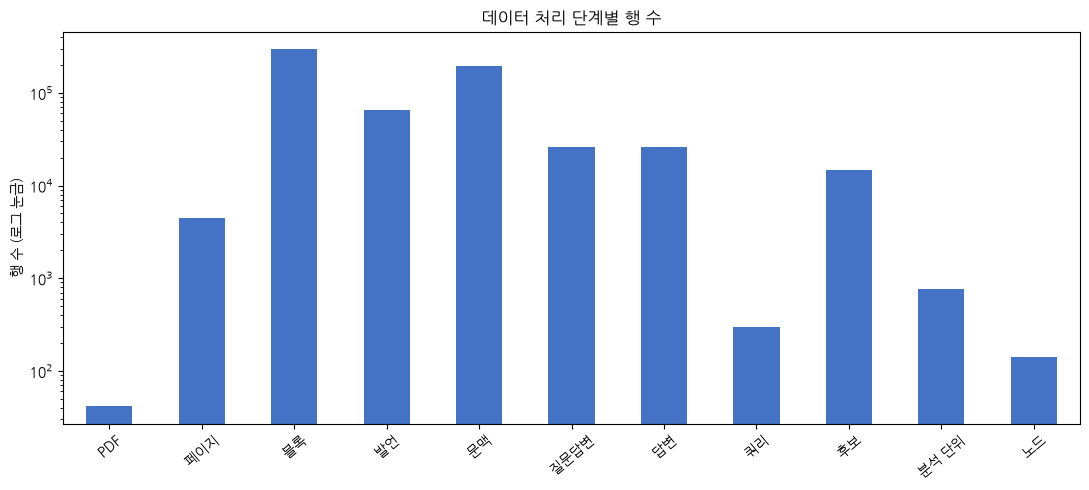

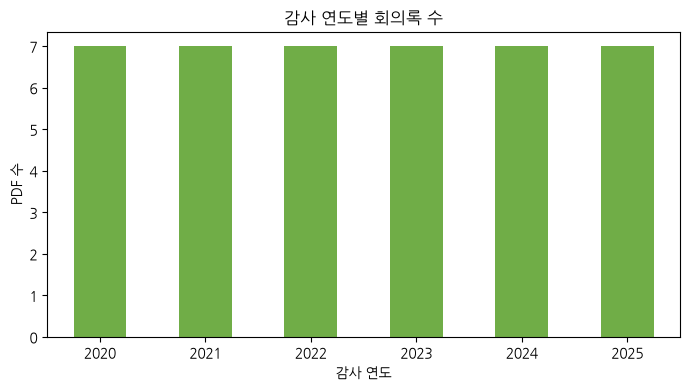

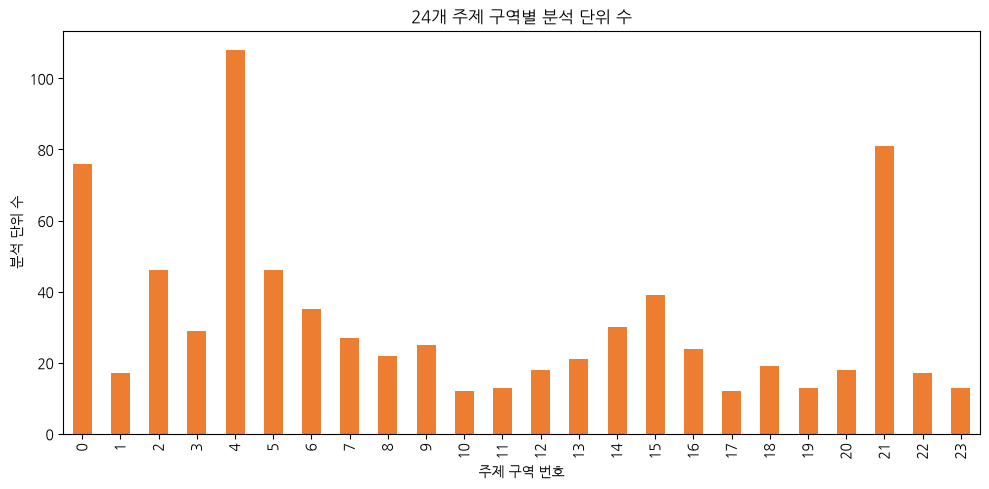

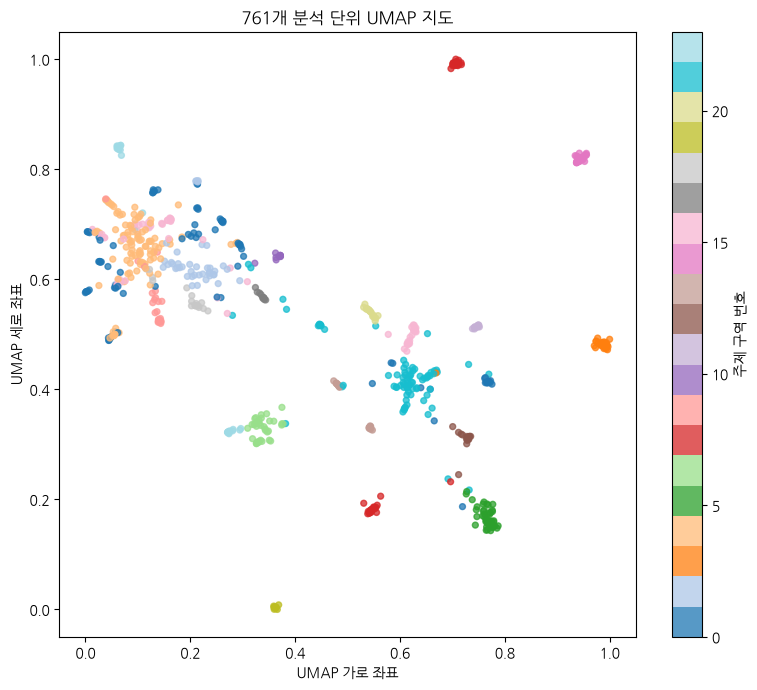

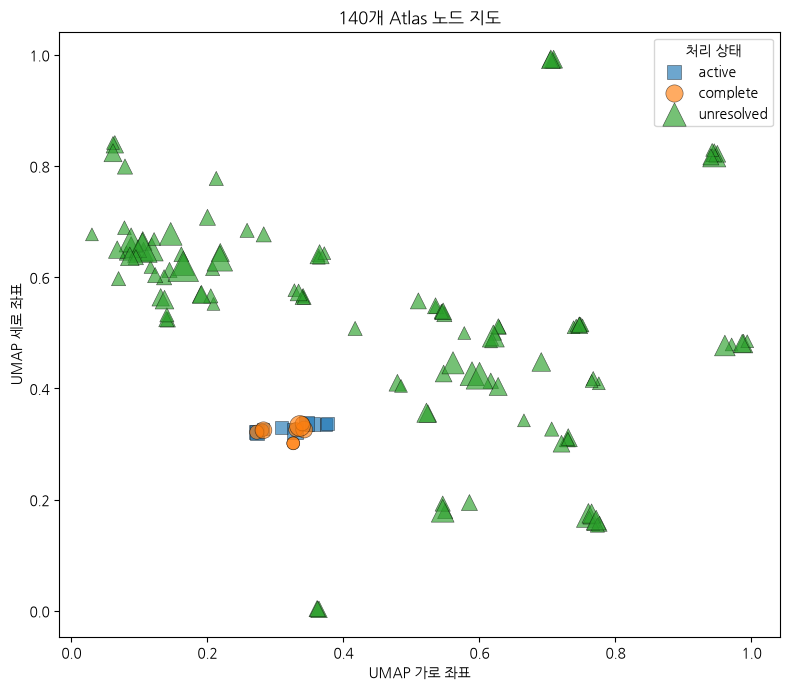

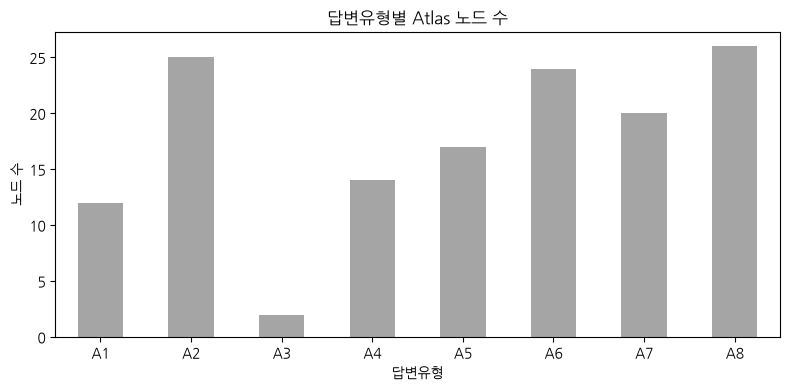

In [20]:
from matplotlib import font_manager
font_candidates = [Path(path) for path in font_manager.findSystemFonts() if Path(path).name == "NanumGothic.ttf"]
if font_candidates:
    font_manager.fontManager.addfont(str(font_candidates[0]))
    plt.rcParams["font.family"] = font_manager.FontProperties(fname=str(font_candidates[0])).get_name()
plt.rcParams["axes.unicode_minus"] = False

pipeline_counts = pd.Series({"PDF": len(registry), "페이지": len(pages), "블록": len(blocks), "발언": len(speaker_turns), "문맥": len(retrieval_segments), "질문답변": len(qa_pairs), "답변": len(answer_units), "쿼리": len(target_issues), "후보": len(retrieval_candidates), "분석 단위": len(decision_groups), "노드": len(atlas_nodes)})
fig, ax = plt.subplots(figsize=(11, 5)); pipeline_counts.plot.bar(ax=ax, color="#4472C4"); ax.set_yscale("log"); ax.set_title("데이터 처리 단계별 행 수"); ax.set_ylabel("행 수 (로그 눈금)"); ax.tick_params(axis="x", rotation=40); fig.tight_layout(); fig.savefig(FIGURE_DIR / "01_pipeline_row_counts.png", dpi=160); plt.show()

year_counts = registry.assign(year=registry.meeting_year.astype(int) + 2000).groupby("year").size()
fig, ax = plt.subplots(figsize=(7, 4)); year_counts.plot.bar(ax=ax, color="#70AD47"); ax.set_title("감사 연도별 회의록 수"); ax.set_xlabel("감사 연도"); ax.set_ylabel("PDF 수"); ax.tick_params(axis="x", rotation=0); fig.tight_layout(); fig.savefig(FIGURE_DIR / "02_minutes_by_year.png", dpi=160); plt.show()

fig, ax = plt.subplots(figsize=(10, 5)); topic_bins.sort_values("cluster_number").plot.bar(x="cluster_number", y="member_count", ax=ax, color="#ED7D31", legend=False); ax.set_title("24개 주제 구역별 분석 단위 수"); ax.set_xlabel("주제 구역 번호"); ax.set_ylabel("분석 단위 수"); fig.tight_layout(); fig.savefig(FIGURE_DIR / "03_topic_bin_counts.png", dpi=160); plt.show()

plot_points = projection_points.merge(topic_members, on="projection_entity_id").merge(topic_bins[["topic_bin_id", "cluster_number"]], on="topic_bin_id")
fig, ax = plt.subplots(figsize=(8, 7)); scatter = ax.scatter(plot_points.x, plot_points.y, c=plot_points.cluster_number, cmap="tab20", s=18, alpha=.75, marker="o"); ax.set_title("761개 분석 단위 UMAP 지도"); ax.set_xlabel("UMAP 가로 좌표"); ax.set_ylabel("UMAP 세로 좌표"); fig.colorbar(scatter, ax=ax, label="주제 구역 번호"); fig.tight_layout(); fig.savefig(FIGURE_DIR / "04_umap_points.png", dpi=160); plt.show()

markers = {"complete": "o", "active": "s", "unresolved": "^"}
fig, ax = plt.subplots(figsize=(8, 7))
for status, group in atlas_nodes.groupby("status"):
    ax.scatter(group.x, group.y, s=group.node_size ** 2, marker=markers.get(status, "D"), alpha=.65, label=status, edgecolor="black", linewidth=.4)
ax.set_title("140개 Atlas 노드 지도"); ax.set_xlabel("UMAP 가로 좌표"); ax.set_ylabel("UMAP 세로 좌표"); ax.legend(title="처리 상태"); fig.tight_layout(); fig.savefig(FIGURE_DIR / "05_atlas_nodes.png", dpi=160); plt.show()

answer_node_counts = atlas_nodes.groupby("answer_type").size().sort_index()
fig, ax = plt.subplots(figsize=(8, 4)); answer_node_counts.plot.bar(ax=ax, color="#A5A5A5"); ax.set_title("답변유형별 Atlas 노드 수"); ax.set_xlabel("답변유형"); ax.set_ylabel("노드 수"); ax.tick_params(axis="x", rotation=0); fig.tight_layout(); fig.savefig(FIGURE_DIR / "06_nodes_by_answer_type.png", dpi=160); plt.show()


그림은 규모와 분포를 이해하기 위한 요약입니다. 색상과 함께 marker, 축 이름, 범례 또는 주제 번호를 사용해 유형을 구분했습니다.


## 25. 최종 처리 결과 요약

원본부터 Atlas 노드까지 주요 결과의 행 수를 한 표로 정리합니다.


In [21]:
summary_counts = {
    "원본 회의록": len(registry), "PDF 페이지": len(pages), "텍스트 블록": len(blocks), "화자 발언": len(speaker_turns),
    "검색 문맥": len(retrieval_segments), "질문·답변 묶음": len(qa_pairs), "답변 단위": len(answer_units),
    "검색 쿼리": len(target_issues), "검색 후보": len(retrieval_candidates), "답변행태 라벨": len(answer_behavior_labels),
    "검토 완료 분석 단위": len(decision_groups), "투영 좌표": len(projection_points), "주제 구역": len(topic_bins), "Atlas 노드": len(atlas_nodes),
}
display(pd.DataFrame({"결과": list(summary_counts), "행 수": list(summary_counts.values())}))


,결과,행 수
0,원본 회의록,42
1,PDF 페이지,4495
2,텍스트 블록,293717
3,화자 발언,65590
4,검색 문맥,196686
5,질문·답변 묶음,25958
6,답변 단위,26063
7,검색 쿼리,297
8,검색 후보,14850
9,답변행태 라벨,769


원본 회의록을 발언과 문맥 단위로 정리하고, TF-IDF와 MiniLM을 이용해 관련 후보를 찾았습니다. 검토 완료 데이터를 문자 TF-IDF와 SVD로 수치화한 뒤, KMeans와 UMAP을 사용해 주제 구역과 2차원 좌표를 만들었습니다. 마지막으로 주제, 처리 상태, 답변유형을 기준으로 140개 노드로 정리했습니다.


## 26. 재현성 검사

원본 해시, 주요 행 수, 좌표 값, 중복 번호, 생성 파일을 자동으로 확인합니다. 결과는 `outputs/RUN_SUMMARY.json`에 저장합니다.


In [22]:
observed = {
    "meeting_pdfs": len(registry), "meeting_pages": len(pages), "text_blocks": len(blocks), "speaker_turns": len(speaker_turns),
    "retrieval_segments": len(retrieval_segments), "qa_pairs": len(qa_pairs), "answer_units": len(answer_units),
    "search_queries": len(target_issues), "search_candidates": len(retrieval_candidates), "answer_behavior_labels": len(answer_behavior_labels),
    "decision_groups": len(decision_groups), "projection_points": len(projection_points), "topic_bins": len(topic_bins), "atlas_nodes": len(atlas_nodes),
}
checks = [{"check": key, "expected": expected_counts[key], "observed": value, "status": "PASS" if value == expected_counts[key] else "FAIL"} for key, value in observed.items()]
checks.extend([
    {"check": "source_hash_check", "expected": 0, "observed": int((~source_hash_check.hash_일치).sum()), "status": "PASS" if source_hash_check.hash_일치.all() else "FAIL"},
    {"check": "finite_projection", "expected": len(projection_points), "observed": int(np.isfinite(projection_points[["x", "y"]]).all(axis=1).sum()), "status": "PASS" if np.isfinite(projection_points[["x", "y"]]).all().all() else "FAIL"},
    {"check": "duplicate_projection_id", "expected": 0, "observed": int(projection_points.projection_entity_id.duplicated().sum()), "status": "PASS" if not projection_points.projection_entity_id.duplicated().any() else "FAIL"},
    {"check": "duplicate_node_membership", "expected": 0, "observed": int(atlas_node_members.projection_entity_id.duplicated().sum()), "status": "PASS" if not atlas_node_members.projection_entity_id.duplicated().any() else "FAIL"},
])
check_table = pd.DataFrame(checks)
required_outputs = sorted(path.relative_to(PROJECT_ROOT).as_posix() for path in [*TABLE_DIR.glob("*"), *FIGURE_DIR.glob("*.png"), *CACHE_DIR.glob("*")])
run_summary = {"status": "PASS" if (check_table.status == "PASS").all() else "FAIL", "run_id": RUN_ID, "canonical_release_id": CANONICAL_RELEASE_ID, "projection_id": PROJECTION_ID, "counts": observed, "checks": checks, "generated_outputs": required_outputs}
(OUTPUT_DIR / "RUN_SUMMARY.json").write_text(json.dumps(run_summary, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")
display(check_table)
assert run_summary["status"] == "PASS", "기준 행 수 또는 무결성 검사가 일치하지 않습니다."


,check,expected,observed,status
0,meeting_pdfs,42,42,PASS
1,meeting_pages,4495,4495,PASS
2,text_blocks,293717,293717,PASS
3,speaker_turns,65590,65590,PASS
4,retrieval_segments,196686,196686,PASS
5,qa_pairs,25958,25958,PASS
6,answer_units,26063,26063,PASS
7,search_queries,297,297,PASS
8,search_candidates,14850,14850,PASS
9,answer_behavior_labels,769,769,PASS


모든 기준 행 수와 무결성 검사를 한 번에 확인했습니다. `RUN_SUMMARY.json`은 실행 환경에서 실제로 생성된 결과 파일과 검사값을 기록합니다.
